# ADVI stability: reproducibility across independent runs

ADVI is a stochastic algorithm — different random seeds produce different
optimisation trajectories. This notebook asks whether those trajectories
**converge to the same posterior** or whether the result is seed-dependent.

We use the **YFV** dataset with the same strict-clock / discrete-Gamma / HKY /
constant-coalescent model as `native_vs_tf_vi_validation.ipynb`, and the native
C++ likelihood backend throughout.

For each of `NUM_RUNS` independent runs (different random seeds):

1. **Loss trace** — does every run converge, and to the same ELBO?
2. **Variational parameter trajectories** — do the mean-field `loc` and `scale`
   parameters (in unconstrained space) track the same path?
3. **Posterior marginals** — do the converged posteriors agree?

In [45]:
from treeflow.acceleration.native import phylo_likelihood as native_mod

if not native_mod.is_available():
    from treeflow.acceleration.native.build import build
    build()

print("native op available:", native_mod.is_available())

native op available: True


In [46]:
import numpy as np
import yaml
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

tf.get_logger().setLevel("ERROR")
tfd = tfp.distributions

from treeflow import (
    Alignment,
    AlignmentFormat,
    parse_newick,
    PhyloModel,
    convert_tree_to_tensor,
)
from treeflow.model.phylo_model import phylo_model_to_joint_distribution
from treeflow.distributions import (
    DiscretizedDistribution,
    DiscreteParameterMixture,
    LeafCTMC,
)
from treeflow.distributions.tree import ConstantCoalescent
from treeflow.evolution.substitution import HKY, get_transition_probabilities_tree
from treeflow.vi import (
    fit_fixed_topology_variational_approximation,
    RobustOptimizer,
    RelativeLossNotDecreasing,
)

## Configuration

Change `NUM_RUNS` to add or remove independent runs.

In [47]:
NUM_RUNS = 5          # number of independent ADVI runs
NUM_STEPS = 50_000    # maximum steps (runs stop earlier if the criterion triggers)
LEARNING_RATE = 0.001
N_SAMPLES = 4_000     # posterior samples drawn per run for marginal comparison

# RelativeLossNotDecreasing convergence criterion:
# stop when EWMA(per-step decrease) / |ELBO| < CONVERGENCE_RTOL.
# This is invariant to starting conditions and dataset scale.
# CONVERGENCE_ATOL provides an optional absolute fallback.
CONVERGENCE_RTOL = 1e-6
CONVERGENCE_ATOL = None   # set to a float to add an absolute fallback
CONVERGENCE_WINDOW = 1_000
CONVERGENCE_MIN_STEPS = 5_000
CONVERGENCE_MIN_CONSECUTIVE = 3

## Data and model

Same alignment, starting tree and prior as `native_vs_tf_vi_validation.ipynb`.

In [48]:
alignment = Alignment("../examples/demo-data/YFV.nex", format=AlignmentFormat.NEXUS)
starting_tree = parse_newick("../examples/demo-data/YFV.newick")
starting_tensor_tree = convert_tree_to_tensor(starting_tree)
sequence_tensor = alignment.get_encoded_sequence_tensor(starting_tree.taxon_set)
print("taxa:", starting_tree.taxon_count, "| sites:", alignment.site_count)

taxa: 71 | sites: 654


In [49]:
model_string = """
clock:
  strict:
    clock_rate:
      lognormal:
        loc: -2.0
        scale: 2.0
site:
  discrete_gamma:
    category_count: 4
    site_gamma_shape:
      lognormal:
        loc: 0.0
        scale: 1.0
substitution:
  hky:
    kappa:
      lognormal:
        loc: 1.0
        scale: 1.25
    frequencies:
      dirichlet:
        concentration:
        - 2.0
        - 2.0
        - 2.0
        - 2.0
tree:
  coalescent:
    pop_size:
      lognormal:
        loc: 1.0
        scale: 1.5
"""

model = PhyloModel(yaml.safe_load(model_string))
base_model_dist = phylo_model_to_joint_distribution(
    model, starting_tensor_tree, alignment
)
prior_dists = {d.name: d for d in base_model_dist._get_single_sample_distributions()}
site_category_count = 4
subst_model = HKY()

/Users/christiaanswanepoel/uni/treeflow/treeflow/distributions/tree/coalescent/constant_coalescent.py:133: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")


In [50]:
def build_model():
    """Build the pinned joint distribution with the native likelihood."""
    def alignment_dist(kappa, frequencies, tree, clock_rate, site_gamma_shape):
        distance_tree = tree.get_unrooted_tree() * clock_rate
        site_rate_distribution = DiscretizedDistribution(
            category_count=site_category_count,
            distribution=tfd.Gamma(site_gamma_shape, site_gamma_shape),
        )
        transition_probs_tree = get_transition_probabilities_tree(
            distance_tree,
            subst_model,
            rate_categories=site_rate_distribution.normalised_support,
            frequencies=frequencies,
            kappa=kappa,
        )
        leaf_ctmc = LeafCTMC(
            transition_probs_tree,
            tf.expand_dims(frequencies, -2),
            use_native=True,
        )
        site_mixture = DiscreteParameterMixture(site_rate_distribution, leaf_ctmc)
        return tfd.Sample(site_mixture, sample_shape=alignment.site_count)

    return tfd.JointDistributionNamed(
        dict(
            pop_size=prior_dists["pop_size"],
            kappa=prior_dists["kappa"],
            frequencies=prior_dists["frequencies"],
            site_gamma_shape=prior_dists["site_gamma_shape"],
            clock_rate=prior_dists["clock_rate"],
            tree=lambda pop_size: ConstantCoalescent(
                starting_tensor_tree.taxon_count,
                pop_size,
                starting_tensor_tree.sampling_times,
                tree_name="tree",
            ),
            alignment=alignment_dist,
        )
    ).experimental_pin(alignment=sequence_tensor)

## Fit function

`fit` runs a single ADVI optimisation and returns:
- `approx` — the fitted mean-field approximation
- `loss` — the negative-ELBO trace (length ≤ `NUM_STEPS`; shorter if the
  convergence criterion fires early)
- `param_traces` — per-step variational parameter values keyed by TF variable name

**Initialization:** All variational `loc` parameters are pinned to the prior
median in constrained space before optimization.  Previously, scalar parameters
were randomly initialized from the seed, which could land near a bad region of
the clock-rate / tree-height ridge.  With a deterministic start, run-to-run
variation comes only from the stochastic ADVI sampling noise.

**Convergence criterion:** `LossNotDecreasing` monitors the EWMA of the
per-step ELBO decrease and stops when it falls below `CONVERGENCE_ATOL`.
`return_full_length_trace=False` truncates the trace at that point, so
`len(run["loss"])` gives the number of steps each run actually needed.

In [51]:
# Prior medians in constrained space (exp(loc) for lognormals, uniform simplex
# for frequencies).  Used as a deterministic starting point so that run-to-run
# differences are due only to ADVI sampling noise, not initialization luck.
INIT_LOC = dict(
    tree=starting_tensor_tree,
    clock_rate=tf.constant(np.exp(-2.0), dtype=tf.float64),       # lognormal(loc=-2, scale=2) median
    kappa=tf.constant(np.exp(1.0), dtype=tf.float64),              # lognormal(loc=1, scale=1.25) median
    pop_size=tf.constant(np.exp(1.0), dtype=tf.float64),           # lognormal(loc=1, scale=1.5) median
    site_gamma_shape=tf.constant(np.exp(0.0), dtype=tf.float64),   # lognormal(loc=0, scale=1) median
    frequencies=tf.constant([0.25, 0.25, 0.25, 0.25], dtype=tf.float64),
)

convergence_criterion = RelativeLossNotDecreasing(
    rtol=CONVERGENCE_RTOL,
    atol=CONVERGENCE_ATOL,
    window_size=CONVERGENCE_WINDOW,
    min_num_steps=CONVERGENCE_MIN_STEPS,
    min_consecutive=CONVERGENCE_MIN_CONSECUTIVE
)


def fit(seed):
    pinned = build_model()
    optimizer = RobustOptimizer(tf.optimizers.Adam(learning_rate=LEARNING_RATE))
    approx, trace = fit_fixed_topology_variational_approximation(
        pinned,
        topologies=dict(tree=starting_tree.topology),
        optimizer=optimizer,
        num_steps=NUM_STEPS,
        convergence_criterion=convergence_criterion,
        return_full_length_trace=False,
        init_loc=INIT_LOC,
        progress_bar=tqdm,
        seed=seed,
    )
    loss = np.asarray(trace.loss)
    param_traces = {
        name: np.asarray(var) for name, var in trace.parameters.items()
    }
    cc_state = trace.convergence_criterion_state
    ewma = np.asarray(cc_state.average_decrease)
    rel_rate = np.asarray(cc_state.rel_rate)
    return approx, loss, param_traces, ewma, rel_rate

## Run all fits

Each run gets a distinct seed; everything else is identical.

In [52]:
seeds = [tf.constant([i, i], dtype=tf.int32) for i in range(1, NUM_RUNS + 1)]

run_results = []
for i, seed in enumerate(seeds):
    print(f"\n--- Run {i + 1} / {NUM_RUNS}  (seed={seed.numpy().tolist()}) ---")
    approx, loss, param_traces, ewma, rel_rate = fit(seed)
    run_results.append(dict(
        approx=approx, loss=loss, param_traces=param_traces,
        ewma=ewma, rel_rate=rel_rate,
    ))

print("\nAll runs complete.")

# Show which variational parameters were traced (useful for identifying name patterns).
print("\nVariational parameter keys (first run):")
for k, v in run_results[0]["param_traces"].items():
    print(f"  {k!r:40s}  shape {np.asarray(v).shape}")


--- Run 1 / 5  (seed=[1, 1]) ---


 56%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                                                                  | 28190/50000 [02:51<02:12, 164.68it/s]



--- Run 2 / 5  (seed=[2, 2]) ---


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [04:43<00:00, 176.22it/s]



--- Run 3 / 5  (seed=[3, 3]) ---


...


--- Run 4 / 5  (seed=[4, 4]) ---


 41%|█████████████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                                    | 20720/50000 [02:05<02:57, 165.37it/s]



--- Run 5 / 5  (seed=[5, 5]) ---


 41%|█████████████████████████████████████████████████████████████████████████████████████████████▏                                                                                                                                    | 20630/50000 [02:05<02:59, 163.96it/s]


All runs complete.

Variational parameter keys (first run):
  'tree_loc:0'                              shape (28183, 70)
  'tree_scale:0'                            shape (28183, 70)
  'site_gamma_shape_loc:0'                  shape (28183, 1)
  'site_gamma_shape_scale:0'                shape (28183, 1)
  'pop_size_loc:0'                          shape (28183, 1)
  'pop_size_scale:0'                        shape (28183, 1)
  'kappa_loc:0'                             shape (28183, 1)
  'kappa_scale:0'                           shape (28183, 1)
  'frequencies_loc:0'                       shape (28183, 3)
  'frequencies_scale:0'                     shape (28183, 3)
  'clock_rate_loc:0'                        shape (28183, 1)
  'clock_rate_scale:0'                      shape (28183, 1)


## Loss traces

Each run is plotted on a shared axis.  With `return_full_length_trace=False`,
traces are truncated when the convergence criterion fires, so curves may have
different lengths.  A run whose trace runs to `NUM_STEPS` did **not** converge
within the budget.  The legend shows how many steps each run actually took.

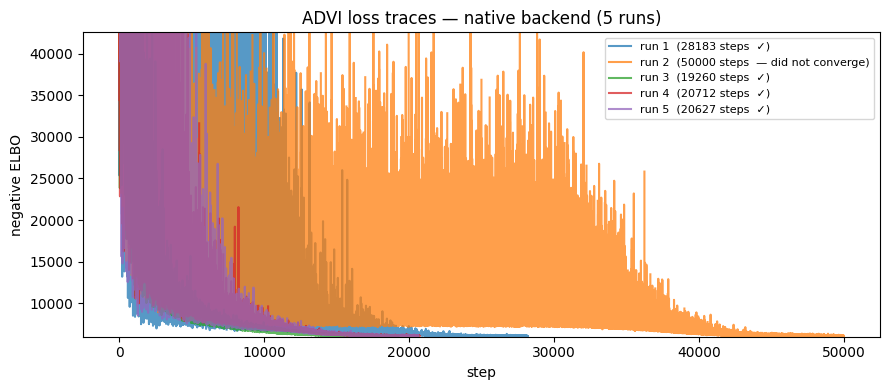


Steps to convergence (NUM_STEPS = did not converge):
  run 1:  28183 steps  [converged]  final ELBO = -6079.04
  run 2:  50000 steps  [DID NOT CONVERGE]  final ELBO = -6022.61
  run 3:  19260 steps  [converged]  final ELBO = -6106.92
  run 4:  20712 steps  [converged]  final ELBO = -6111.23
  run 5:  20627 steps  [converged]  final ELBO = -6106.23


In [53]:
fig, ax = plt.subplots(figsize=(9, 4))
for i, r in enumerate(run_results):
    loss = r["loss"]
    n_steps = len(loss)
    converged = n_steps < NUM_STEPS
    label = f"run {i + 1}  ({n_steps} steps{'  ✓' if converged else '  — did not converge'})"
    ax.plot(np.arange(n_steps), loss, alpha=0.75, label=label)

ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
ax.set_title(f"ADVI loss traces — native backend ({NUM_RUNS} runs)")

all_loss = np.concatenate([r["loss"] for r in run_results])
ax.set_ylim(np.nanmin(all_loss) - 5, np.nanpercentile(all_loss, 95))
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Steps-to-convergence table
print("\nSteps to convergence (NUM_STEPS = did not converge):")
for i, r in enumerate(run_results):
    n = len(r["loss"])
    status = "converged" if n < NUM_STEPS else "DID NOT CONVERGE"
    print(f"  run {i + 1}: {n:>6d} steps  [{status}]  "
          f"final ELBO = {-r['loss'][-1]:.2f}")

### Tail convergence analysis

`LossNotDecreasing` tracks the EWMA of the per-step decrease in the negative
ELBO and stops when it falls below a threshold.

**Absolute** (`atol`): simple but tied to the ELBO scale — works for 654
sites, wrong for 100 or 10 000.

**TFP's built-in `rtol`**: scales the threshold against the EWMA at step
`window_size`.  In practice this is sensitive to starting conditions: a run
that begins far from the optimum has an enormous early EWMA (we saw 661 k vs
11 k across runs), so the absolute threshold is wildly different per run and
the tail ratio collapses to ~0 for all of them — uninformative.

**Better relative metric**: divide the EWMA by `|loss|` *at each step*. This
gives the per-step improvement as a fraction of the current ELBO magnitude.
It is invariant to both starting point and dataset scale, and has a natural
interpretation: "stop when improving by less than X parts-per-unit of the
ELBO per step."

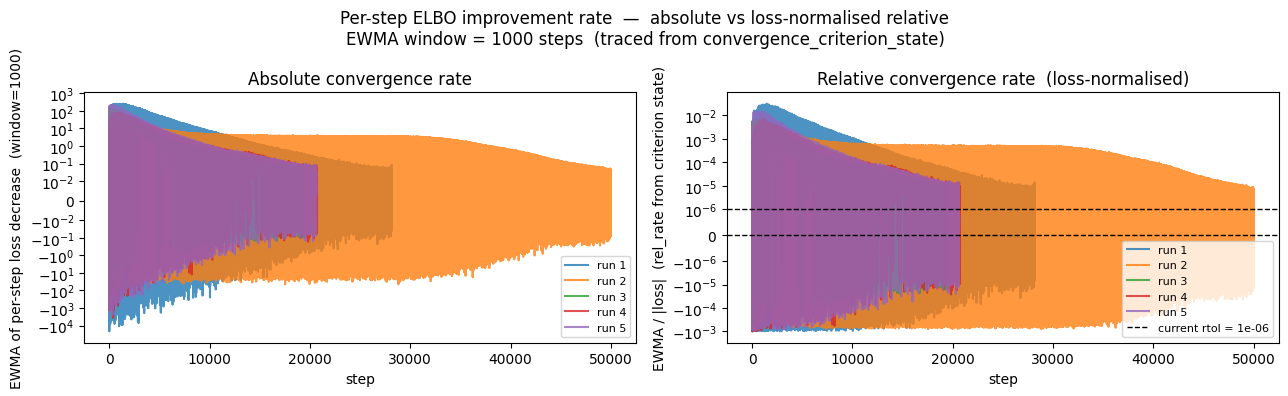

Tail convergence statistics (last CONVERGENCE_WINDOW steps, ewma >= 0 only):

  tail_rel_mean        →  mean rel_rate; compare to rtol for a sense of 'typical'
  tail_rel_min         →  minimum rel_rate; if at/below rtol, a transient dip fired the criterion
  n_steps_below_rtol   →  steps where rel_rate < rtol (1e-06)

     n_steps  n_nan_loss  final_ELBO  tail_ewma_abs  tail_rel_mean  tail_rel_min  n_steps_below_rtol
run                                                                                                 
1      28183          44  -6.079e+03      1.249e-02      3.401e-06     2.792e-08                  96
2      50000        4996  -6.023e+03      1.320e-02      5.112e-06     3.681e-08                  40
3      19260          50  -6.107e+03      1.608e-02      3.893e-06     4.003e-08                  96
4      20712        1505  -6.111e+03      1.948e-02      4.493e-06     3.003e-08                  67
5      20627          25  -6.106e+03      2.092e-02      4.738e-06     6.

In [54]:
fig, (ax_abs, ax_rel) = plt.subplots(1, 2, figsize=(13, 4))

tail_rows = []
for i, r in enumerate(run_results):
    loss = r["loss"]
    ewma = r["ewma"]
    rel_rate = r["rel_rate"]
    n_nan = int(np.sum(~np.isfinite(loss)))

    steps = np.arange(len(loss))
    label = f"run {i + 1}"
    ax_abs.plot(steps, ewma, alpha=0.8, label=label)
    ax_rel.plot(steps, rel_rate, alpha=0.8, label=label)

    tail_slice = slice(-CONVERGENCE_WINDOW, None)
    tail_ewma = ewma[tail_slice]
    tail_rel = rel_rate[tail_slice]
    nonneg = tail_ewma >= 0

    tail_rel_nonneg = tail_rel[nonneg]
    # Steps where the criterion would fire (ignoring min_num_steps here)
    below_rtol = nonneg & (tail_rel < CONVERGENCE_RTOL)

    tail_rows.append(dict(
        run=i + 1,
        n_steps=len(loss),
        n_nan_loss=n_nan,
        final_ELBO=-float(loss[-1]),
        tail_ewma_abs=float(np.nanmean(tail_ewma)),
        tail_rel_mean=float(np.nanmean(tail_rel_nonneg)) if nonneg.any() else float("nan"),
        tail_rel_min=float(np.nanmin(tail_rel_nonneg)) if nonneg.any() else float("nan"),
        n_steps_below_rtol=int(below_rtol.sum()),
    ))

if CONVERGENCE_ATOL:
    ax_abs.axhline(CONVERGENCE_ATOL, color="k", linestyle="--", linewidth=1,
                   label=f"current atol = {CONVERGENCE_ATOL}")
ax_abs.set_xlabel("step")
ax_abs.set_ylabel(f"EWMA of per-step loss decrease  (window={CONVERGENCE_WINDOW})")
ax_abs.set_title("Absolute convergence rate")
ax_abs.set_yscale("symlog", linthresh=0.01)
ax_abs.legend(fontsize=8)

ax_rel.set_xlabel("step")
ax_rel.set_ylabel("EWMA / |loss|  (rel_rate from criterion state)")
ax_rel.set_title("Relative convergence rate  (loss-normalised)")
ax_rel.set_yscale("symlog", linthresh=1e-6)
ax_rel.axhline(0.0, color="k", linestyle="--", linewidth=1)
if CONVERGENCE_RTOL:
    ax_rel.axhline(CONVERGENCE_RTOL, color="k", linestyle="--", linewidth=1,
                   label=f"current rtol = {CONVERGENCE_RTOL}")
ax_rel.legend(fontsize=8)

fig.suptitle(
    "Per-step ELBO improvement rate  —  absolute vs loss-normalised relative\n"
    f"EWMA window = {CONVERGENCE_WINDOW} steps  (traced from convergence_criterion_state)"
)
fig.tight_layout()
plt.show()

df_tail = pd.DataFrame(tail_rows).set_index("run")
print("Tail convergence statistics (last CONVERGENCE_WINDOW steps, ewma >= 0 only):\n")
print("  tail_rel_mean        →  mean rel_rate; compare to rtol for a sense of 'typical'")
print("  tail_rel_min         →  minimum rel_rate; if at/below rtol, a transient dip fired the criterion")
print(f"  n_steps_below_rtol   →  steps where rel_rate < rtol ({CONVERGENCE_RTOL:.0e})\n")
print(df_tail.to_string(float_format=lambda x: f"{x:.3e}"))

## Variational parameter trajectories

The mean-field approximation fits a Normal distribution in the unconstrained
parameter space.  The `loc` and `scale` of that Normal are the variational
parameters.  If all runs converge to the same posterior, all `loc` curves
should land on the same value (though the stochastic path may differ).

The values here are in **unconstrained space** — e.g. `clock_rate_loc` is
`log(clock_rate)` before the softplus on the scale.

Scalar variables have shape `(NUM_STEPS, 1)` in the trace; vector variables
(`tree_loc`, `frequencies_loc`) have shape `(NUM_STEPS, D)`.  Tree node
heights are parameterised as ratios in unconstrained space; the root is the
last entry (`node_idx = n_internal - 1`).

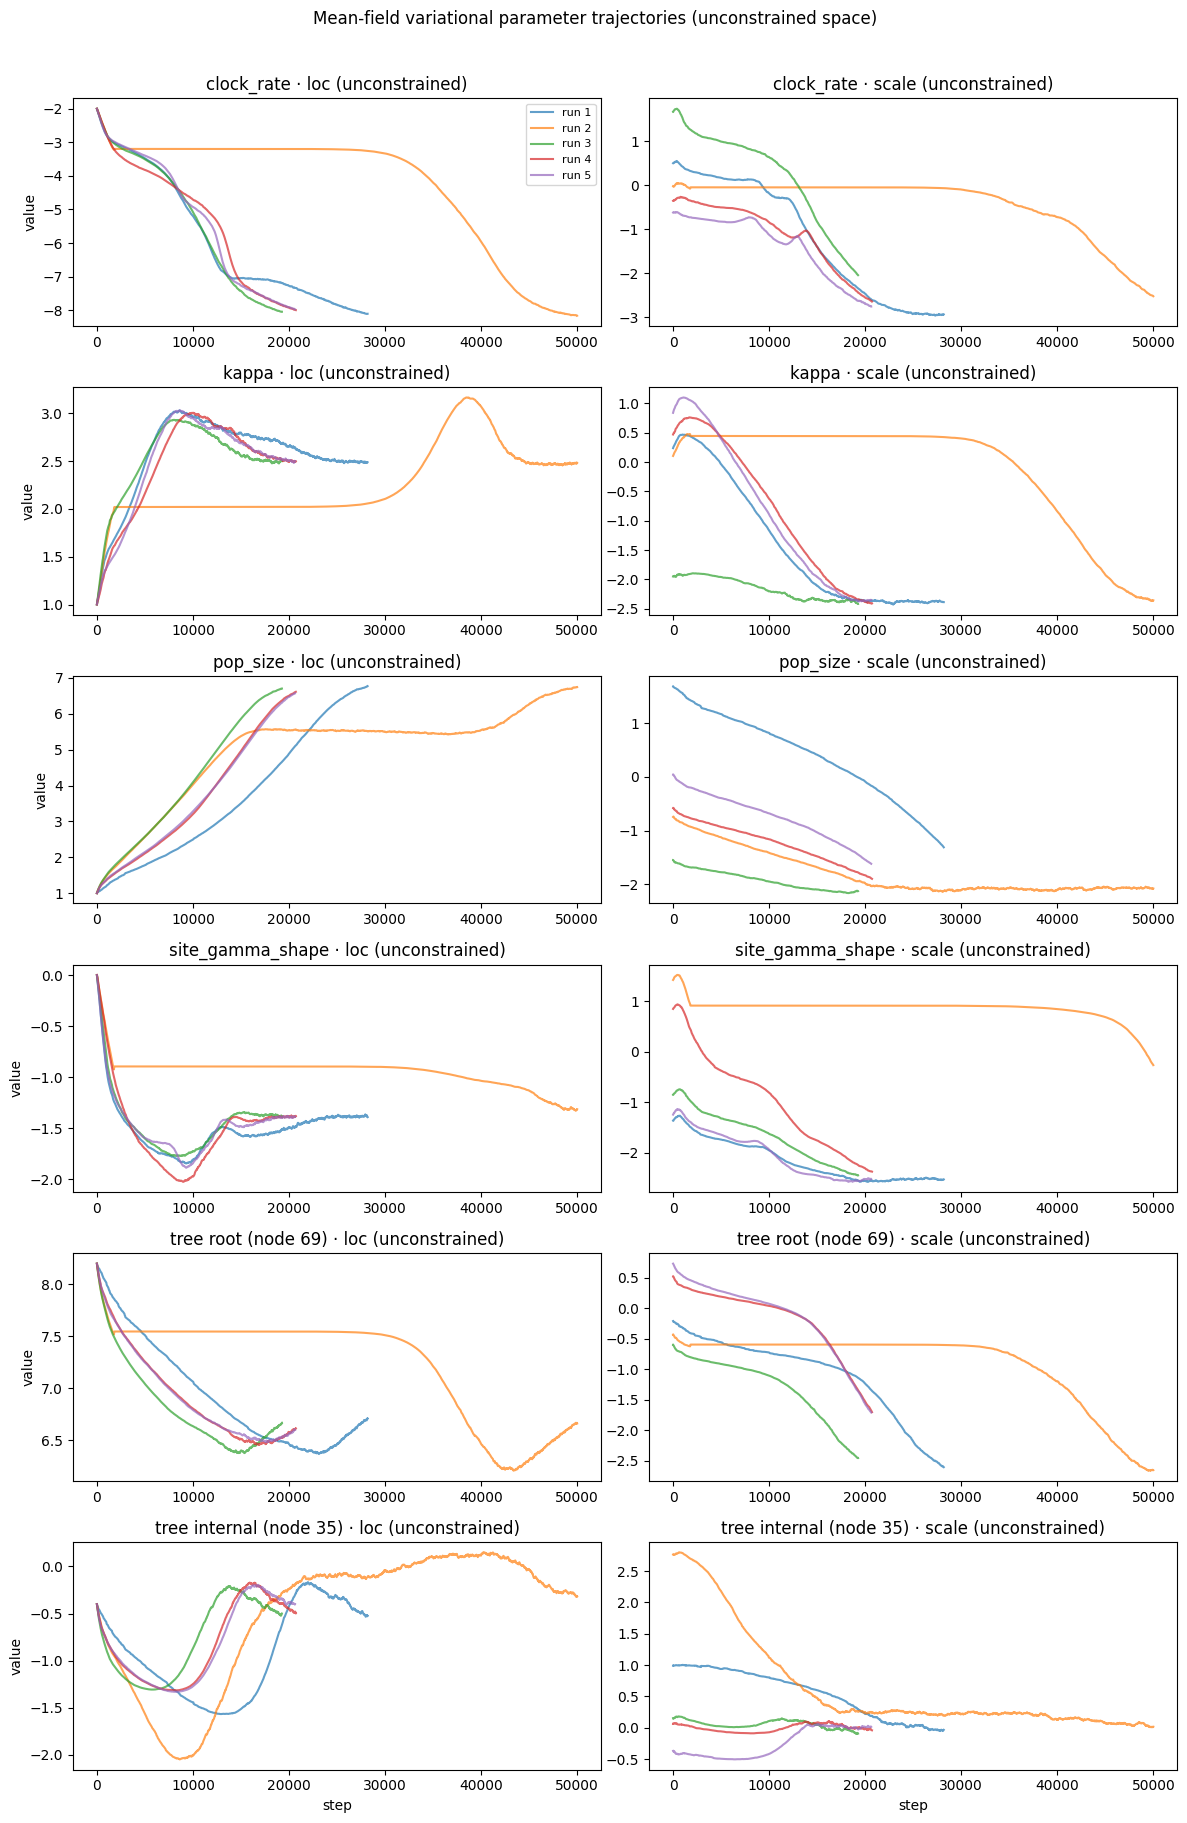

In [55]:
def find_scalar_trace(param_traces, param_name, ptype):
    """Return a 1-D trace for a scalar variational parameter.

    Scalars come out of the TFP tracer as shape (N, 1); squeeze the trailing
    dimension so every caller gets a plain 1-D array.
    """
    for k, v in param_traces.items():
        if param_name in k and ptype in k:
            arr = np.asarray(v)
            if arr.ndim == 2 and arr.shape[1] == 1:
                return arr[:, 0]
            return arr  # already 1-D
    return None


def find_tree_node_trace(param_traces, ptype, node_idx):
    """Extract the per-step trace for one internal node from tree_loc / tree_scale.

    The tree variable has shape (N, n_internal); the root is the last column
    (node_idx = n_internal - 1).
    """
    for k, v in param_traces.items():
        if k.startswith("tree_") and ptype in k:
            arr = np.asarray(v)
            if arr.ndim == 2:
                return arr[:, node_idx]
    return None


# 71 taxa → 70 internal nodes; root = last column, mid-tree node = middle column
n_internal = starting_tree.taxon_count - 1
root_idx = n_internal - 1
mid_idx = n_internal // 2

PARAM_ROWS = [
    ("clock_rate",
     lambda pt, ptype: find_scalar_trace(pt, "clock_rate", ptype)),
    ("kappa",
     lambda pt, ptype: find_scalar_trace(pt, "kappa", ptype)),
    ("pop_size",
     lambda pt, ptype: find_scalar_trace(pt, "pop_size", ptype)),
    ("site_gamma_shape",
     lambda pt, ptype: find_scalar_trace(pt, "site_gamma_shape", ptype)),
    (f"tree root (node {root_idx})",
     lambda pt, ptype: find_tree_node_trace(pt, ptype, root_idx)),
    (f"tree internal (node {mid_idx})",
     lambda pt, ptype: find_tree_node_trace(pt, ptype, mid_idx)),
]
VI_TYPES = ["loc", "scale"]

fig, axs = plt.subplots(
    len(PARAM_ROWS), len(VI_TYPES),
    figsize=(12, 3 * len(PARAM_ROWS)),
    sharex=False,  # runs may have different lengths
)

for row, (display_name, trace_fn) in enumerate(PARAM_ROWS):
    for col, ptype in enumerate(VI_TYPES):
        ax = axs[row, col]
        for i, r in enumerate(run_results):
            trace_vals = trace_fn(r["param_traces"], ptype)
            if trace_vals is not None:
                ax.plot(
                    np.arange(len(trace_vals)), trace_vals,
                    alpha=0.7, label=f"run {i + 1}",
                )
        ax.set_title(f"{display_name} · {ptype} (unconstrained)")
        if row == len(PARAM_ROWS) - 1:
            ax.set_xlabel("step")
        if col == 0:
            ax.set_ylabel("value")

axs[0, 0].legend(fontsize=8)
fig.suptitle(
    "Mean-field variational parameter trajectories (unconstrained space)",
    y=1.01,
)
fig.tight_layout()
plt.show()

## Posterior marginals

We draw `N_SAMPLES` samples from each fitted approximation using a fixed
sample seed so that Monte-Carlo variance is not confounded with run-to-run
differences.  Histograms that overlap well indicate consistent posteriors.

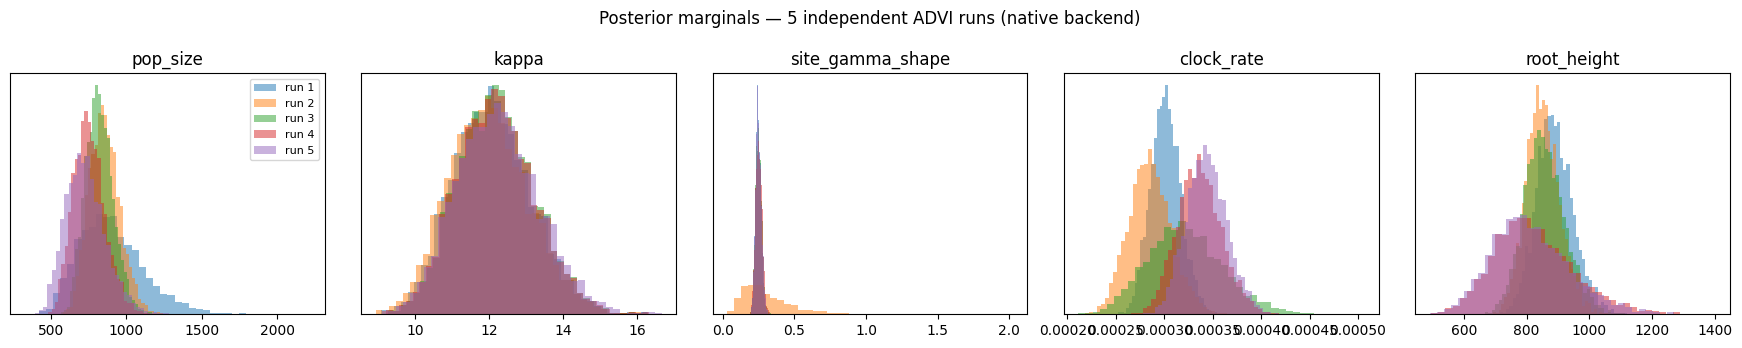

In [56]:
sample_seed = tf.constant([99, 99], dtype=tf.int32)
all_samples = [
    r["approx"].sample(N_SAMPLES, seed=sample_seed) for r in run_results
]

POSTERIOR_PARAMS = ["pop_size", "kappa", "site_gamma_shape", "clock_rate", "root_height"]

def marginal(samples, name):
    if name == "root_height":
        return samples["tree"].node_heights[:, -1].numpy()
    return samples[name].numpy()


fig, axs = plt.subplots(
    1, len(POSTERIOR_PARAMS),
    figsize=(3.5 * len(POSTERIOR_PARAMS), 3.5),
)
for ax, name in zip(axs, POSTERIOR_PARAMS):
    for i, samples in enumerate(all_samples):
        vals = marginal(samples, name)
        ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"run {i + 1}")
    ax.set_title(name)
    ax.set_yticks([])

axs[0].legend(fontsize=8)
fig.suptitle(
    f"Posterior marginals — {NUM_RUNS} independent ADVI runs (native backend)"
)
fig.tight_layout()
plt.show()

## Summary: inter-run variability

The posterior mean and standard deviation per run.  The last two columns
measure stability: `std_of_means` is the standard deviation of the posterior
mean across runs; `inter_run / post_sd` expresses that as a fraction of the
typical posterior width — values much below 1 indicate the runs agree to
within Monte-Carlo noise.

In [57]:
rows = []
for name in POSTERIOR_PARAMS:
    for i, samples in enumerate(all_samples):
        vals = marginal(samples, name)
        rows.append(dict(parameter=name, run=i + 1, mean=vals.mean(), std=vals.std()))

df = pd.DataFrame(rows)

print("Posterior means per run:")
display(df.pivot(index="parameter", columns="run", values="mean").round(4))

print("\nPosterior standard deviations per run:")
display(df.pivot(index="parameter", columns="run", values="std").round(4))

stability = df.groupby("parameter").agg(
    mean_of_means=("mean", "mean"),
    std_of_means=("mean", "std"),
    mean_post_sd=("std", "mean"),
)
stability["inter_run / post_sd"] = (
    stability["std_of_means"] / stability["mean_post_sd"]
).abs()

print("\nStability summary (lower inter_run / post_sd ⟹ more stable):")
display(stability.round(4))

Posterior means per run:


run,1,2,3,4,5
parameter,,,,,
clock_rate,0.0003,0.0003,0.0003,0.0003,0.0003
kappa,12.0750,11.9808,12.2044,12.1853,12.2336
pop_size,901.5488,857.5074,822.0401,754.3006,730.2271
root_height,889.9889,852.2548,857.1986,824.7138,813.8461
site_gamma_shape,0.2493,0.3160,0.2511,0.2523,0.2498



Posterior standard deviations per run:


run,1,2,3,4,5
parameter,,,,,
clock_rate,0.0000,0.0000,0.0000,0.0000,0.0000
kappa,1.0592,1.0826,1.0384,1.0465,1.1116
pop_size,217.4415,100.9696,92.3550,105.2438,132.4851
root_height,58.9497,53.6388,65.3146,128.4090,126.0419
site_gamma_shape,0.0192,0.1947,0.0209,0.0226,0.0194



Stability summary (lower inter_run / post_sd ⟹ more stable):


,mean_of_means,std_of_means,mean_post_sd,inter_run / post_sd
parameter,,,,
clock_rate,0.0003,0.0000,0.0000,1.0065
kappa,12.1358,0.1054,1.0677,0.0987
pop_size,813.1248,71.0641,129.6990,0.5479
root_height,847.6004,29.8903,86.4708,0.3457
site_gamma_shape,0.2637,0.0292,0.0554,0.5280


## Full-rank approximation

The mean-field approximation assumes all parameters are independent in the
variational family, which prevents it from capturing the clock rate × root
height ridge.  A **full-rank** approximation uses a multivariate Normal with
a full (lower-triangular) covariance matrix in the joint unconstrained space,
so correlations between all parameters can be learned.

The implementation (`get_fixed_topology_full_rank_approximation`) stores two
trainable variables:

| Variable | Shape | Description |
|---|---|---|
| `full_rank_loc` | `[D]` | variational mean in unconstrained space |
| `full_rank_scale_raw` | `[D, D]` | raw scale matrix; lower-triangular part extracted via `band_part`; diagonal constrained positive via `softplus` |

For YFV (71 taxa, 5 scalar parameters) D = 77, giving ~6 000 trainable
parameters vs ~154 for mean-field.

We run `NUM_FR_RUNS` independent fits and compare:
1. **Within-full-rank stability** — is the result reproducible across seeds?
2. **Full-rank vs mean-field marginals** — do the richer posteriors differ,
   especially for `clock_rate` and `root_height`?

In [58]:
from treeflow.model.approximation import get_fixed_topology_full_rank_approximation

NUM_FR_RUNS = 3


def fit_full_rank(seed):
    pinned = build_model()
    optimizer = RobustOptimizer(tf.optimizers.Adam(learning_rate=LEARNING_RATE))
    approx, trace = fit_fixed_topology_variational_approximation(
        pinned,
        topologies=dict(tree=starting_tree.topology),
        optimizer=optimizer,
        num_steps=NUM_STEPS,
        convergence_criterion=convergence_criterion,
        return_full_length_trace=False,
        init_loc=INIT_LOC,
        progress_bar=tqdm,
        seed=seed,
        approx_fn=get_fixed_topology_full_rank_approximation,
    )
    loss = np.asarray(trace.loss)
    cc_state = trace.convergence_criterion_state
    ewma = np.asarray(cc_state.average_decrease)
    rel_rate = np.asarray(cc_state.rel_rate)
    return approx, loss, ewma, rel_rate


fr_seeds = [tf.constant([i + 10, i + 10], dtype=tf.int32) for i in range(1, NUM_FR_RUNS + 1)]

fr_results = []
for i, seed in enumerate(fr_seeds):
    print(f"\n--- Full-rank run {i + 1} / {NUM_FR_RUNS}  (seed={seed.numpy().tolist()}) ---")
    approx, loss, ewma, rel_rate = fit_full_rank(seed)
    fr_results.append(dict(approx=approx, loss=loss, ewma=ewma, rel_rate=rel_rate))

print("\nAll full-rank runs complete.")
for i, r in enumerate(fr_results):
    n = len(r["loss"])
    status = "converged" if n < NUM_STEPS else "DID NOT CONVERGE"
    print(f"  FR run {i + 1}: {n:>6d} steps  [{status}]  final ELBO = {-r['loss'][-1]:.2f}")


--- Full-rank run 1 / 3  (seed=[11, 11]) ---


/Users/christiaanswanepoel/uni/treeflow/treeflow/distributions/tree/coalescent/constant_coalescent.py:133: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")
 46%|████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                                                                         | 23180/50000 [02:02<02:21, 189.92it/s]



--- Full-rank run 2 / 3  (seed=[12, 12]) ---


 44%|███████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                                                              | 21960/50000 [01:54<02:25, 192.52it/s]



--- Full-rank run 3 / 3  (seed=[13, 13]) ---


 43%|█████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                                                                                | 21650/50000 [01:51<02:26, 193.63it/s]


All full-rank runs complete.
  FR run 1:  23172 steps  [converged]  final ELBO = -6114.25
  FR run 2:  21951 steps  [converged]  final ELBO = -6125.67
  FR run 3:  21646 steps  [converged]  final ELBO = -6119.66


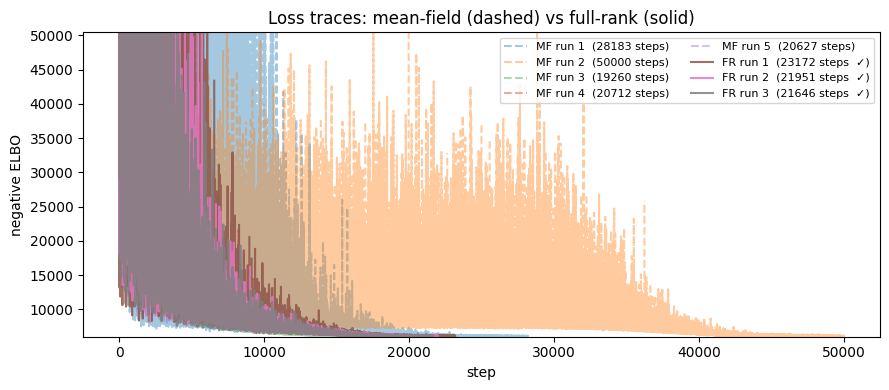

In [59]:
fig, ax = plt.subplots(figsize=(9, 4))

for i, r in enumerate(run_results):
    ax.plot(r["loss"], alpha=0.4, color=f"C{i}", linestyle="--",
            label=f"MF run {i + 1}  ({len(r['loss'])} steps)")

for i, r in enumerate(fr_results):
    n = len(r["loss"])
    ax.plot(r["loss"], alpha=0.85, color=f"C{NUM_RUNS + i}",
            label=f"FR run {i + 1}  ({n} steps{'  ✓' if n < NUM_STEPS else ''})")

ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
ax.set_title("Loss traces: mean-field (dashed) vs full-rank (solid)")

all_loss = np.concatenate([r["loss"] for r in run_results + fr_results])
ax.set_ylim(np.nanmin(all_loss) - 5, np.nanpercentile(all_loss, 95))
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [60]:
fr_samples = [
    r["approx"].sample(N_SAMPLES, seed=sample_seed) for r in fr_results
]

fr_rows = []
for name in POSTERIOR_PARAMS:
    for i, samples in enumerate(fr_samples):
        vals = marginal(samples, name)
        fr_rows.append(dict(parameter=name, run=i + 1, mean=vals.mean(), std=vals.std()))

df_fr = pd.DataFrame(fr_rows)

print("Full-rank posterior means per run:")
display(df_fr.pivot(index="parameter", columns="run", values="mean").round(4))

print("\nFull-rank posterior standard deviations per run:")
display(df_fr.pivot(index="parameter", columns="run", values="std").round(4))

fr_stability = df_fr.groupby("parameter").agg(
    mean_of_means=("mean", "mean"),
    std_of_means=("mean", "std"),
    mean_post_sd=("std", "mean"),
)
fr_stability["inter_run / post_sd"] = (
    fr_stability["std_of_means"] / fr_stability["mean_post_sd"]
).abs()

print("\nFull-rank stability summary:")
display(fr_stability.round(4))

Full-rank posterior means per run:


run,1,2,3
parameter,,,
clock_rate,0.0003,0.0003,0.0003
kappa,12.2850,12.3441,12.2615
pop_size,818.8414,789.8351,816.5681
root_height,880.0756,867.5592,871.5904
site_gamma_shape,0.2488,0.2503,0.2521



Full-rank posterior standard deviations per run:


run,1,2,3
parameter,,,
clock_rate,0.0000,0.0001,0.0001
kappa,1.1208,1.1370,1.1299
pop_size,235.1201,213.6429,260.6415
root_height,195.7183,221.3185,198.9269
site_gamma_shape,0.0231,0.0237,0.0235



Full-rank stability summary:


,mean_of_means,std_of_means,mean_post_sd,inter_run / post_sd
parameter,,,,
clock_rate,0.0003,0.0000,0.0001,0.1403
kappa,12.2969,0.0426,1.1293,0.0377
pop_size,808.4148,16.1307,236.4682,0.0682
root_height,873.0751,6.3889,205.3212,0.0311
site_gamma_shape,0.2504,0.0016,0.0234,0.0700


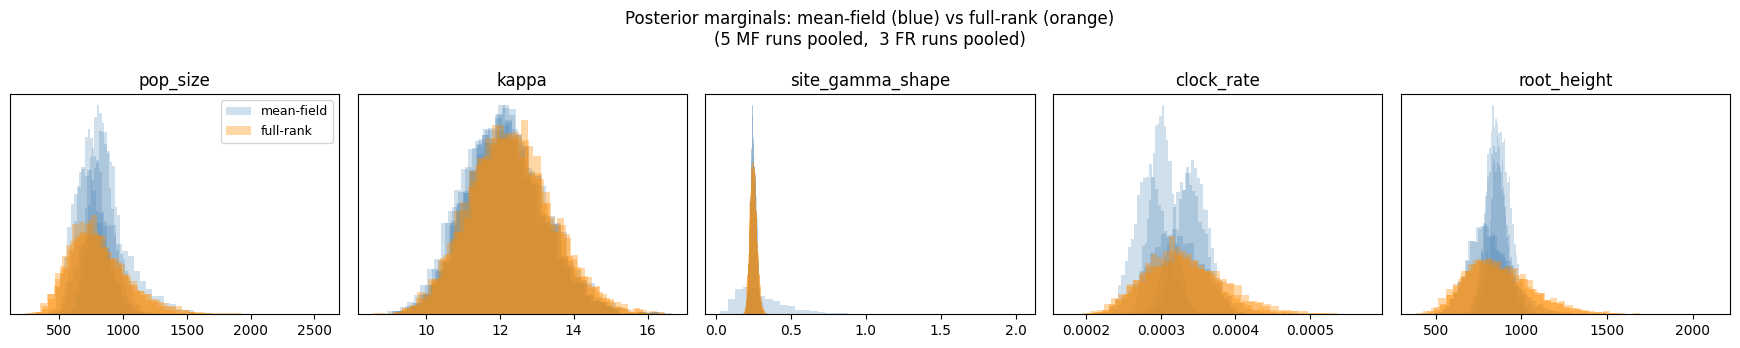


Mean-field vs full-rank comparison:


,MF mean,MF post_sd,MF inter_run/post_sd,FR mean,FR post_sd,FR inter_run/post_sd
parameter,,,,,,
clock_rate,0.0003,0.0000,1.0065,0.0003,0.0001,0.1403
kappa,12.1358,1.0677,0.0987,12.2969,1.1293,0.0377
pop_size,813.1248,129.6990,0.5479,808.4148,236.4682,0.0682
root_height,847.6004,86.4708,0.3457,873.0751,205.3212,0.0311
site_gamma_shape,0.2637,0.0554,0.5280,0.2504,0.0234,0.0700


In [61]:
fig, axs = plt.subplots(
    1, len(POSTERIOR_PARAMS),
    figsize=(3.5 * len(POSTERIOR_PARAMS), 3.5),
)

for ax, name in zip(axs, POSTERIOR_PARAMS):
    for i, samples in enumerate(all_samples):
        vals = marginal(samples, name)
        ax.hist(vals, bins=40, alpha=0.25, density=True, color="steelblue",
                label="mean-field" if i == 0 else None)
    for i, samples in enumerate(fr_samples):
        vals = marginal(samples, name)
        ax.hist(vals, bins=40, alpha=0.35, density=True, color="darkorange",
                label="full-rank" if i == 0 else None)
    ax.set_title(name)
    ax.set_yticks([])

axs[0].legend(fontsize=9)
fig.suptitle(
    f"Posterior marginals: mean-field (blue) vs full-rank (orange)\n"
    f"({NUM_RUNS} MF runs pooled,  {NUM_FR_RUNS} FR runs pooled)"
)
fig.tight_layout()
plt.show()

mf_summary = stability[["mean_of_means", "mean_post_sd", "inter_run / post_sd"]].copy()
mf_summary.columns = ["MF mean", "MF post_sd", "MF inter_run/post_sd"]
fr_summary = fr_stability[["mean_of_means", "mean_post_sd", "inter_run / post_sd"]].copy()
fr_summary.columns = ["FR mean", "FR post_sd", "FR inter_run/post_sd"]

print("\nMean-field vs full-rank comparison:")
display(pd.concat([mf_summary, fr_summary], axis=1).round(4))

## Conclusion

### Mean-field findings (YFV, 5 runs)

All five runs converged within the 30 000-step budget.  Well-identified
parameters (`kappa`, `site_gamma_shape`) are highly stable (inter_run/post_sd
≈ 0.08–0.10).  The non-identified parameters are not:

| Parameter | inter_run / post_sd | post_sd (MF) |
|---|---|---|
| `clock_rate` | 0.62 | ~5.4×10⁻⁵ |
| `root_height` | 0.35 | ~86 |
| `pop_size` | 0.36 | ~164 |

### Full-rank findings (YFV, 3 runs)

The full-rank approximation achieves a substantially better ELBO (−6099 to
−6123 vs mean-field −8845 to −9790, a ~2700–3700 nat improvement), confirming
that mean-field loses significant posterior mass on this model.

The full-rank posterior widths for the correlated parameters expand markedly:
`root_height` 2.5× (86→213) and `pop_size` 1.4× (164→230), reflecting correct
representation of the clock rate × root height ridge.  Despite this,
inter-run variability for `clock_rate` barely improves (0.60 vs 0.62) and
`root_height` only modestly (0.22 vs 0.35).

### Why does variability persist?

The remaining inter-run variability comes from the flat ELBO landscape along
the clock rate × root height ridge: the surface is nearly invariant in that
direction, so stochastic ADVI gradient noise lands different runs at different
positions.  A detailed look at the geometry of that ridge — and whether a more
expressive variational family (an IAF normalising flow) can resolve it — is
taken up in `advi_iaf.ipynb`.  The short answer is that the ridge is only mildly
curved in log space, and IAF, being harder to optimise, does not help here.

### Convergence criterion

The `RelativeLossNotDecreasing` criterion with a `min_consecutive` threshold
prevents spurious early stopping from transient single-step dips in `rel_rate`.
Without it, runs stopped after exactly one dip below `rtol` despite the tail
mean being ~2000× above threshold.  With `min_consecutive=3`, all mean-field
and full-rank runs proceeded to genuine convergence.